In [4]:
import spectral as sp
from spectral import *
import spectral.graphics as graphics

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from time import time
import numpy as np
import colorsys
import cv2
from PIL import Image
import pytesseract
import re

from skimage.color import rgb2hsv
from skimage.measure import label, regionprops
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

# Import datasets, classifiers and performance metrics
from sklearn import datasets, metrics, svm
from sklearn.model_selection import train_test_split

from scipy.cluster.hierarchy import dendrogram, linkage

import pandas as pd
import os
import inspect

from dotenv import load_dotenv

from datetime import datetime
# Activate the ipympl backend
%matplotlib widget

In [42]:
# read the header
img_num="188" 
image_path= f"../images/HS/{img_num}/results/REFLECTANCE_{img_num}.hdr"


hdr = sp.envi.open(image_path)
wvl = hdr.bands.centers
rows, cols, n_bands = hdr.nrows, hdr.ncols, hdr.nbands
meta = hdr.metadata

# This is safe to do when your image is small
img = hdr.load()

In [43]:
#find the key (band number) and value(wavelength) of NIR and RED

wl=meta['wavelength']
x_ticks=list(range(len(wl)))
wl_dic=dict(zip(x_ticks,wl))


wl_dic={item[0]:float(item[1]) for item in wl_dic.items()}
waveLengths=[int(float(w)) for w in wl]

# the convention is the represented wavelength of red and nir is 669 and 829 corrspondly
# so we find in the wavelenghts of the image the nearst wavelength for each of them.
red_wl= 669
nir_wl=829

key_red,val_red = min(wl_dic.items(),key=lambda item:abs(item[1]-red_wl))
key_nir,val_nir=min(wl_dic.items(),key=lambda item:abs(item[1]-nir_wl))

#calculate ndvi
red=img[:,:,key_red]
nir=img[:,:,key_nir]
np.seterr(divide='ignore', invalid='ignore') # Ignore division by zero warnings
ndvi_ = (nir - red) / (nir + red)



/tmp/ipykernel_930335/824303206.py:23: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ndvi_ = (nir - red) / (nir + red)


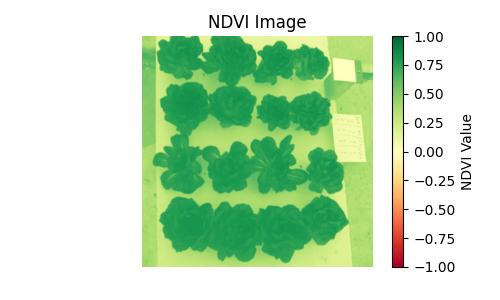

In [44]:
plt.figure(figsize=(5, 3))
plt.imshow(ndvi_, cmap='RdYlGn', vmin=-1, vmax=1) # NDVI values range from -1 to 1
plt.colorbar(label='NDVI Value')
plt.title("NDVI Image")
plt.axis("off")
plt.show()

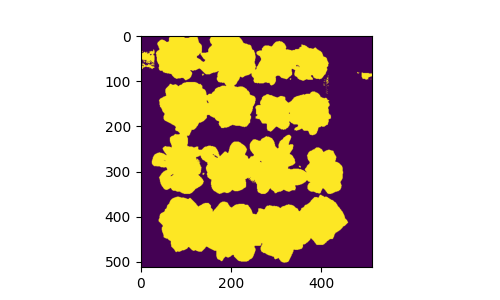

In [45]:
ndvi_above_th=ndvi_>0.6
plt.figure(figsize=(5, 3))
plt.imshow(ndvi_above_th)
plt.show()



#### create object of hs image

In [46]:
import sys
sys.path.append('..')

import importlib
import src.image_processing.hyper_spectral_image

# 1. Reload the base module
importlib.reload(src.image_processing.hyper_spectral_image)

# # 2. Re-import the specific class/function if needed
from src.image_processing.hyper_spectral_image import HyperSpectralImage



In [47]:
df=pd.read_csv(f"../images/HS/bounding_boxes_BENI_ATAROT.csv")
local_annotation_file_path="../images/HS/bounding_boxes_BENI_ATAROT.csv"
RGB_bands=meta['default bands']
COMPUTE_NDI=True
ndi_table_directory_path= "ndi_tables"
hs_img=HyperSpectralImage(
                    img,
                    wl,
                    RGB_bands,
                    img_num,
                    ROTATE= True,
                    ndi_tuple=False,
                    create_ndi_table=COMPUTE_NDI,
                    ndi_table_directory_path=ndi_table_directory_path,
                    ndi_storage_method="hdf5",
                    ANNOTATION_PATH=local_annotation_file_path,
                    SPLIT_IMAGE_TO_OBJECTS=True,
                    acquisition_date=None,
                    longitude=meta['longitude'],
                    latitude=meta['latitude'],
                    object_filter_method="by_ndvi",
                    ndvi_threshold=0.6,
                    hsv_filter_thresholds={
                        "hue_threshold": None,
                        "saturation_threshold": None,
                        "value_threshold": None
      }
                    ) 

In [84]:
objs_df=hs_img.objs_df
len(objs_df['label_name'].unique().tolist())

15

In [79]:
img_obj=objs_df.iloc[15]
x1,y1=img_obj['bbox_x'],img_obj['bbox_y']
x2,y2=x1+img_obj['bbox_width'],y1+img_obj['bbox_height']
print(x1,y1,x2,y2)

2 254 159 361


In [ ]:
binary_cropped_image = hs_img.leaves_binary_img[y1:y2, x1:x2]
plt.figure(figsize=(3,5))
plt.imshow(binary_cropped_image)
plt.show()

In [ ]:
binary_leaves_of_obj = objs_df.iloc[14]['obj_pixels']
plt.figure(figsize=(3,5))
plt.imshow(binary_leaves_of_obj)
plt.show()

In [ ]:

for idx, row in objs_df.iterrows():
    binary_leaves_of_obj=row['obj_pixels']
    plt.figure(figsize=(3,5))
    plt.imshow(binary_leaves_of_obj)
    plt.show()
    #print(hs_img.NDVI(SPLIT=True,leaves_bi_of_obj=binary_leaves_of_obj))

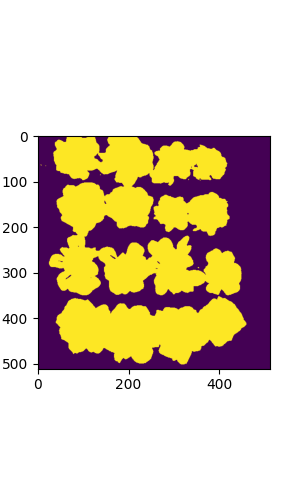

In [64]:
hs_img.leaves_binary_img
plt.figure(figsize=(3,5))
plt.imshow(hs_img.leaves_binary_img)